In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [53]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_fixation_probability(
    path: str,
    population_size: int,
    selection_vals=(0.0, 0.01, 0.1),
    linestyles=('-', '--', ':'),
    inset_xlim=(0.99, 2.1),
    inset_ylim=(1e-5, 1e-2),
    figsize=(6, 3),
):
    """
    Plot fixation probability curves (main + log-scale inset) for a given population size.
    
    Parameters
    ----------
    path : str
        Directory containing your CSV files.
    population_size : int
        The N in your filename and plot title.
    selection_vals : sequence of float
        Which selection coefficients to plot.
    linestyles : sequence of str
        Line styles for each selection coefficient.
    inset_xlim : tuple of float
        x–limits for the inset (log view).
    inset_ylim : tuple of float
        y–limits for the inset (log view).
    figsize : tuple of float
        Figure size for the main plot.
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Main curves
    for sel, ls in zip(selection_vals, linestyles):
        pattern = (
            f"fixation_probability_population_size_{population_size}_"
            f"size_model_constant_Schweinsberg*"
            f"viability_constant_selection_{sel}_selection_period_0.06283_"
            "nb_simulations_500000_shifted_0.0.csv"
        )
        files = glob.glob(f"{path}{pattern}")
        if not files:
            raise FileNotFoundError(f"No files match pattern: {pattern}")
        df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
        df = df.sort_values('parameter')
        ax.plot(df['parameter'],
                df['fixation_probability'],
                linestyle=ls,
                marker='o',
                c='black',
                label=f"s = {sel}")

    ax.set_ylim(0, 0.050)
    ax.set_xlabel('parameter')
    ax.set_ylabel('Fixation probability')
    ax.set_title(f'Viability selection (N = {population_size})', loc='left')
    ax.grid(True)
    #ax.legend(title="Selection coeff.", loc='upper right')

    # Log-scale inset
    axins = inset_axes(ax, width="25%", height="40%", loc='upper left', borderpad=3)
    for sel, ls in zip(selection_vals, linestyles):
        pattern = (
            f"fixation_probability_population_size_{population_size}_"
            f"size_model_constant_Schweinsberg*"
            f"viability_constant_selection_{sel}_selection_period_0.06283_"
            "nb_simulations_500000_shifted_0.0.csv"
        )
        df = pd.concat([pd.read_csv(f) for f in glob.glob(f"{path}{pattern}")],
                       ignore_index=True).sort_values('parameter')
        axins.plot(df['parameter'],
                   df['fixation_probability'],
                   linestyle=ls, marker='o', c='black')

    axins.set_yscale('log')
    axins.set_xlim(*inset_xlim)
    axins.set_ylim(*inset_ylim)
    axins.set_xticks([1.5, 2.0])
    axins.set_yticks([1e-4, 1e-1])
    axins.tick_params(labelsize=8)
    axins.grid(True, which='both', ls=':')

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_1278925/551655481.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


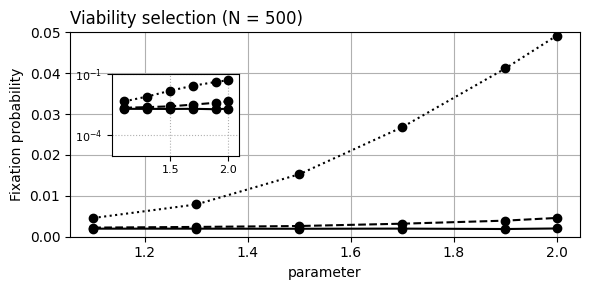

In [54]:
plot_fixation_probability(
    path='../src/simulations/',
    population_size=500,   
    selection_vals=[0.0, 0.01, 0.1],
    linestyles=['-', '--', ':']
)

/tmp/ipykernel_1278925/551655481.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


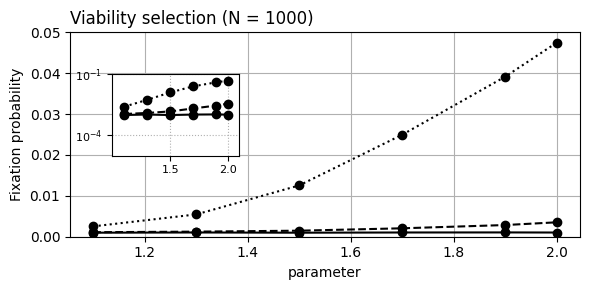

In [ ]:
plot_fixation_probability(
    path='../src/simulations/',
    population_size=1000,   
    selection_vals=[0.0, 0.01, 0.1],
    linestyles=['-', '--', ':']
)

/tmp/ipykernel_1278925/551655481.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


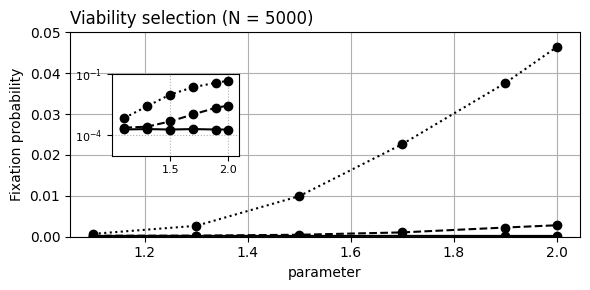

In [71]:
plot_fixation_probability(
    path='../src/simulations/',
    population_size=5000,   
    selection_vals=[0.0, 0.01, 0.1],
    linestyles=['-', '--', ':']
)

In [2]:
# alpha^(1/(alpha-1)) * s^ (1/(alpha-1))
alpha = 2
s = 0.01
alpha**(1/(alpha-1)) * s** (1/(alpha-1))

0.02